In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("库导入完成！")


库导入完成！


In [2]:
# 加载数据
df = pd.read_csv('train_processed.csv')

print(f"数据形状: {df.shape}")
print(f"数据列数: {len(df.columns)}")
print("\n前5行数据:")
print(df.head())


数据形状: (11167, 33)
数据列数: 33

前5行数据:
   线路类型  是否c2c  是否生鲜妥投及时    保价金额  始发城市  目的城市   寄件人id   收件人id  寄件是否内部  配送超时时长  \
0     2      0         0   1.402   146   125  183889  300000      -1  427863   
1     2      1         0   0.971   309   117  147363  300000      -1  427847   
2     2      0         0  56.729   134     4   21570  146233      -1  -23039   
3     2      0         1  66.737   229   222  226496  308949      -1  427699   
4     2      0         0  11.434   179   168  122138   50377      -1  427758   

   ...    理赔差额 异常原因_编码  进线渠道_编码  商品类型_编码 进线人身份_编码  妥投到进线时长_分桶      虚报比例  \
0  ...  803.46       1        2        1        0           6  5.559892   
1  ...  856.89       1        0       12        0           6  6.301588   
2  ...  233.30       0        0        0        1           5  1.954755   
3  ...  189.44       1        2       11        1           6  2.530929   
4  ...  135.44       0        4       11        0           0  6.117435   

  生鲜妥投组合类别_编码  始发网点类别_target_enco

In [3]:
# 数分位回归模型进行风险标注
print("=== 数分位回归风险标注 ===")

# 1. 创建数分位指标
print("1. 创建数分位指标...")
df['数分位指标'] = df['理赔差额'] / (df['实际赔付金额'] + 1)
print(f"数分位指标统计:")
print(df['数分位指标'].describe())

# 2. 导入数分位回归相关库
from sklearn.linear_model import QuantileRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import joblib

print("\n2. 准备数分位回归特征...")

# 选择用于回归的特征（排除目标变量）
feature_cols = [col for col in df.columns if col not in ['索赔金额','实际赔付金额','数分位指标','虚报比例']]
print(f"回归特征数量: {len(feature_cols)}")

# 处理特征数据
X = df[feature_cols].copy()

# 对分类变量进行编码
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# 填充缺失值
X = X.fillna(X.median())

# 标准化特征
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

y = df['数分位指标'].copy()

print(f"特征矩阵形状: {X_scaled.shape}")
print(f"目标变量形状: {y.shape}")


=== 数分位回归风险标注 ===
1. 创建数分位指标...
数分位指标统计:
count    11167.000000
mean         3.021528
std          4.854940
min          0.000080
25%          0.734756
50%          1.657949
75%          3.359080
max         98.222084
Name: 数分位指标, dtype: float64

2. 准备数分位回归特征...
回归特征数量: 30
特征矩阵形状: (11167, 30)
目标变量形状: (11167,)


In [4]:
# 3. 训练数分位回归模型 - 使用85%和97%分位数
print("\n3. 训练数分位回归模型...")

# 定义分位数：85%和97%
quantiles = [0.85, 0.97]
quantile_models = {}

print("训练不同分位数的回归模型:")
for q in quantiles:
    print(f"\n训练 {q*100:.0f}% 分位数模型...")
    
    # 使用QuantileRegressor
    model = QuantileRegressor(quantile=q, alpha=0.1)
    model.fit(X_scaled, y)
    
    # 交叉验证评估
    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='neg_mean_absolute_error')
    print(f"  CV MAE: {-cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    quantile_models[q] = model

print("\n数分位回归模型训练完成！")



3. 训练数分位回归模型...
训练不同分位数的回归模型:

训练 85% 分位数模型...
  CV MAE: 3.6495 (+/- 0.1405)

训练 97% 分位数模型...
  CV MAE: 11.0353 (+/- 0.4264)

数分位回归模型训练完成！


In [5]:
# 4. 进行风险标注 - 按照您的要求调整分位数阈值
print("\n4. 进行风险标注...")

# 使用训练好的模型进行预测
predictions = {}
for q, model in quantile_models.items():
    pred = model.predict(X_scaled)
    predictions[q] = pred
    print(f"{q*100:.0f}%分位数预测范围: [{pred.min():.4f}, {pred.max():.4f}]")

# 基于调整后的分位数预测进行风险标注
def assign_risk_label(row):
    """基于数分位指标和分位数预测进行风险标注"""
    actual_value = row['actual_value']  # 修正：使用actual_value而不是数分位指标
    q85_pred = row['q85_pred']  # 85%分位数
    q97_pred = row['q97_pred']  # 97%分位数
    
    # 调整后的风险标注规则：
    # 小于85%分位数 -> 合理诉求 (占比≥85%)
    # 85%-97%分位数 -> 诉求偏高 (占比约12%)
    # 大于97%分位数 -> 严重超额 (占比<3%)
    if actual_value <= q85_pred:
        return "合理诉求"
    elif actual_value <= q97_pred:
        return "诉求偏高"
    else:
        return "严重超额"

# 创建预测结果DataFrame
pred_df = pd.DataFrame({
    'q85_pred': predictions[0.85],
    'q97_pred': predictions[0.97],
    'actual_value': df['数分位指标']
})

# 应用风险标注
df['风险标注'] = pred_df.apply(assign_risk_label, axis=1)

# 统计风险标注结果
print("\n风险标注结果统计:")
risk_counts = df['风险标注'].value_counts()
risk_percentages = df['风险标注'].value_counts(normalize=True) * 100

for label in ['合理诉求', '诉求偏高', '严重超额']:
    count = risk_counts.get(label, 0)
    percentage = risk_percentages.get(label, 0)
    print(f"{label}: {count} 条记录 ({percentage:.2f}%)")

# 检查是否满足分布要求
total_records = len(df)
reasonable_count = (df['风险标注'] == '合理诉求').sum()
excessive_count = (df['风险标注'] == '严重超额').sum()

reasonable_pct = reasonable_count / total_records * 100
excessive_pct = excessive_count / total_records * 100

print(f"\n分布检查:")
print(f"合理诉求占比: {reasonable_pct:.2f}% (目标: ≥85%)")
print(f"严重超额占比: {excessive_pct:.2f}% (目标: <3%)")

if reasonable_pct >= 85 and excessive_pct < 3:
    print("✓ 分布要求已满足！")
else:
    print("✗ 分布要求未满足，需要进一步调整")

print("\n风险标注完成！")


4. 进行风险标注...
85%分位数预测范围: [4.8350, 5.4633]
97%分位数预测范围: [13.4428, 13.4428]

风险标注结果统计:
合理诉求: 9493 条记录 (85.01%)
诉求偏高: 1339 条记录 (11.99%)
严重超额: 335 条记录 (3.00%)

分布检查:
合理诉求占比: 85.01% (目标: ≥85%)
严重超额占比: 3.00% (目标: <3%)
✓ 分布要求已满足！

风险标注完成！



5. 可视化分析...


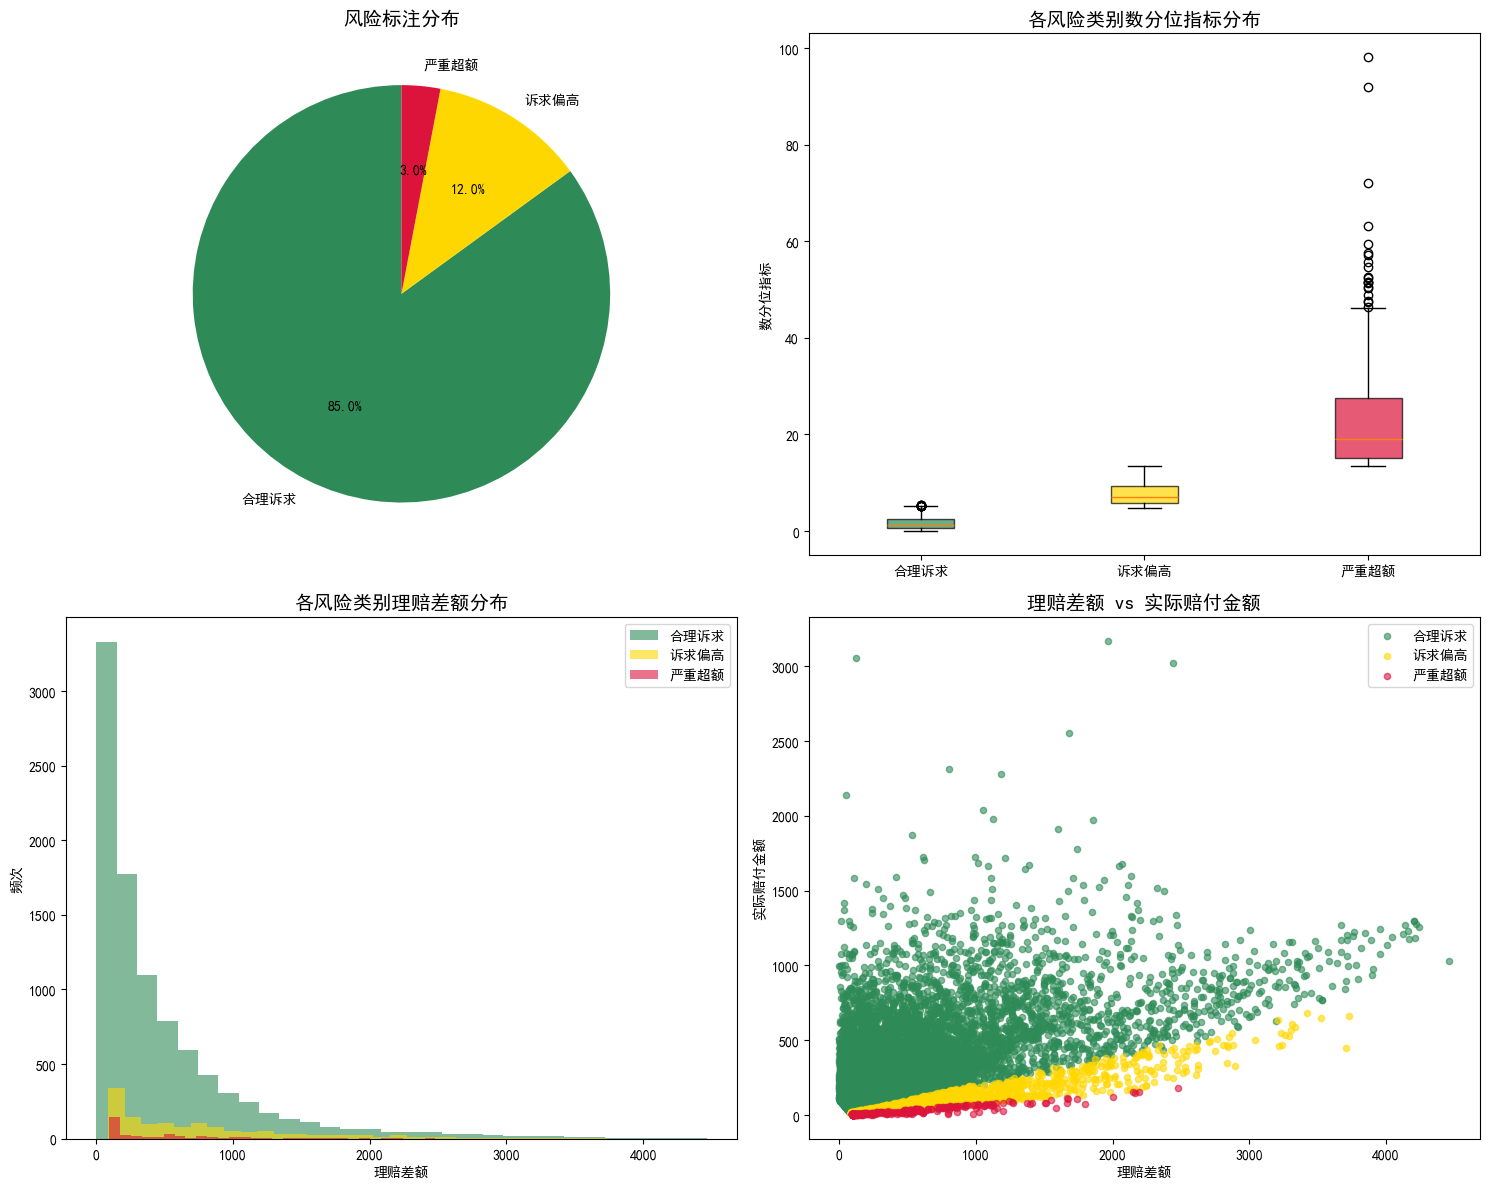

可视化分析完成！


In [6]:
# 5. 可视化分析
print("\n5. 可视化分析...")

# 创建图表
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. 风险标注分布饼图
ax1 = axes[0, 0]
risk_counts = df['风险标注'].value_counts()
colors = ['#2E8B57', '#FFD700', '#DC143C']  # 绿色、金色、红色
wedges, texts, autotexts = ax1.pie(risk_counts.values, labels=risk_counts.index, 
                                   autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('风险标注分布', fontsize=14, fontweight='bold')

# 2. 数分位指标分布箱线图
ax2 = axes[0, 1]
risk_labels = ['合理诉求', '诉求偏高', '严重超额']
box_data = [df[df['风险标注'] == label]['数分位指标'].values for label in risk_labels]
bp = ax2.boxplot(box_data, labels=risk_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_title('各风险类别数分位指标分布', fontsize=14, fontweight='bold')
ax2.set_ylabel('数分位指标')

# 3. 理赔差额分布直方图
ax3 = axes[1, 0]
for i, label in enumerate(risk_labels):
    subset = df[df['风险标注'] == label]['理赔差额']
    ax3.hist(subset, bins=30, alpha=0.6, label=label, color=colors[i])
ax3.set_title('各风险类别理赔差额分布', fontsize=14, fontweight='bold')
ax3.set_xlabel('理赔差额')
ax3.set_ylabel('频次')
ax3.legend()

# 4. 实际赔付金额 vs 索赔金额散点图
ax4 = axes[1, 1]
for i, label in enumerate(risk_labels):
    subset = df[df['风险标注'] == label]
    ax4.scatter(subset['理赔差额'], subset['实际赔付金额'], 
               alpha=0.6, label=label, color=colors[i], s=20)
ax4.set_title('理赔差额 vs 实际赔付金额', fontsize=14, fontweight='bold')
ax4.set_xlabel('理赔差额')
ax4.set_ylabel('实际赔付金额')
ax4.legend()

plt.tight_layout()
plt.show()

print("可视化分析完成！")



6. 各风险类别密度分布分析...
85%分位数阈值: 4.9216
97%分位数阈值: 13.4428


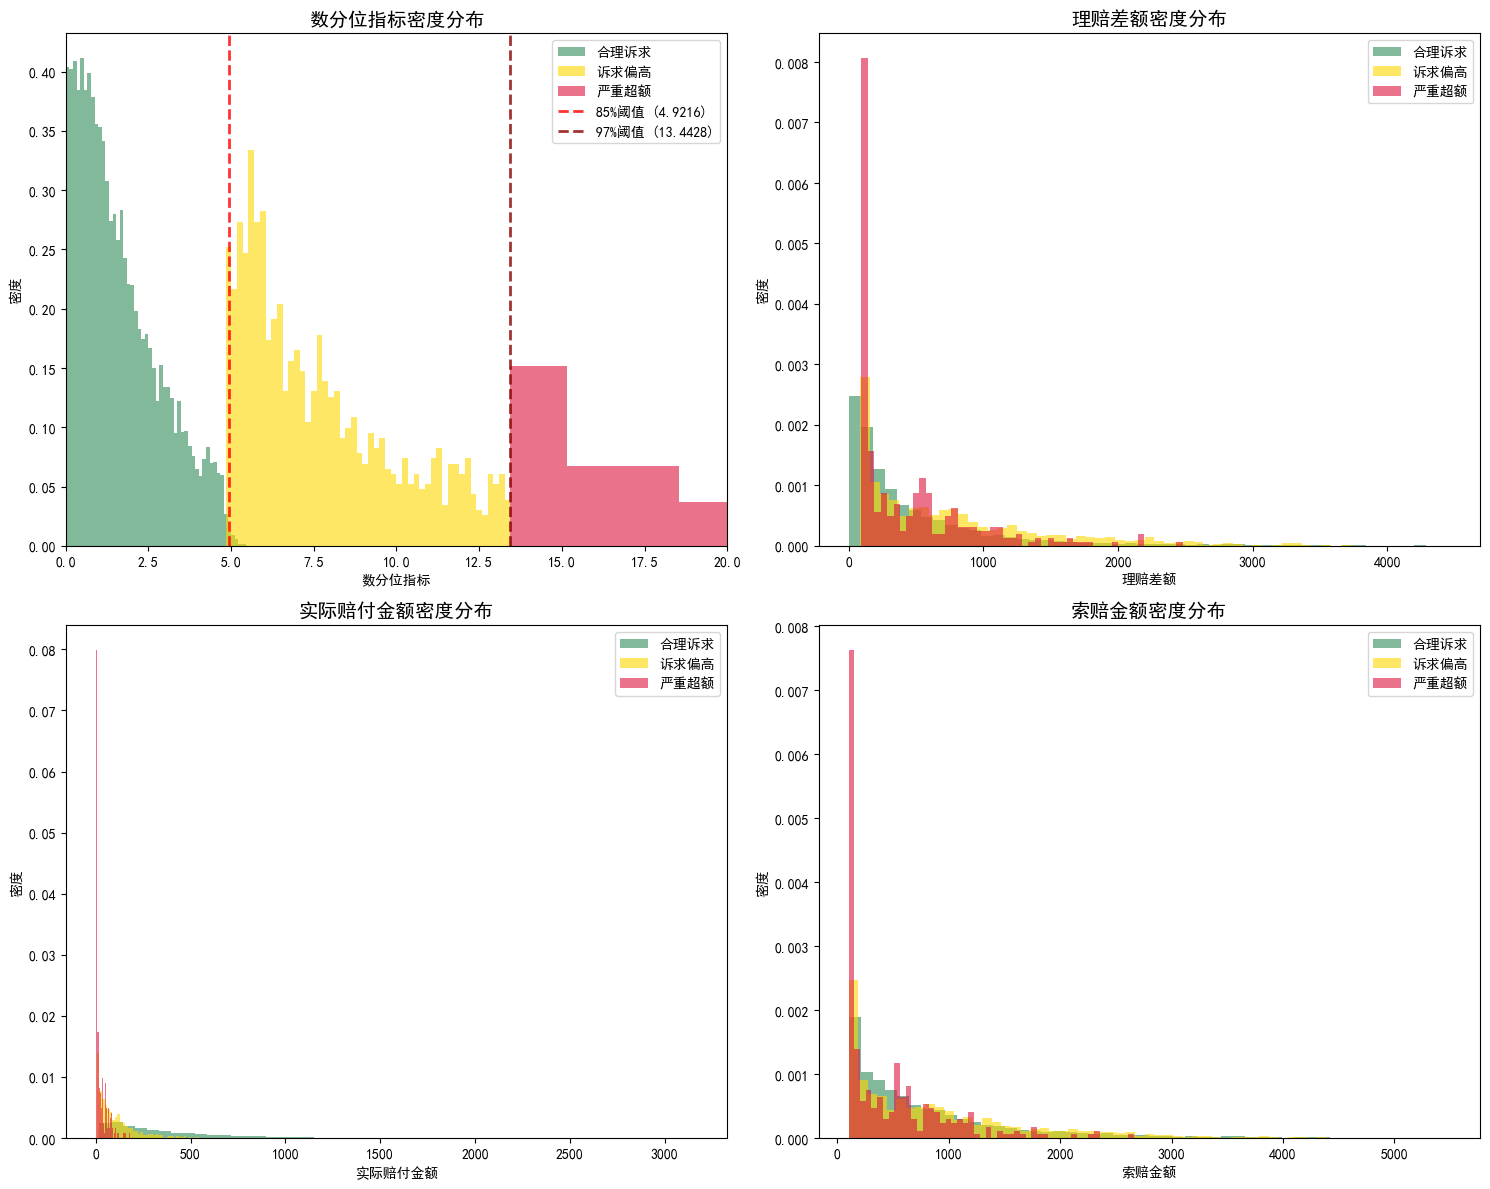

阈值区间密度分布分析完成！


In [7]:
# 6. 各风险类别密度分布分析 - 阈值区间密度
print("\n6. 各风险类别密度分布分析...")

# 获取阈值
q85_threshold = df['数分位指标'].quantile(0.85)
q97_threshold = df['数分位指标'].quantile(0.97)

print(f"85%分位数阈值: {q85_threshold:.4f}")
print(f"97%分位数阈值: {q97_threshold:.4f}")

# 创建密度图 - 只显示阈值区间
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. 数分位指标密度分布 - 阈值区间
ax1 = axes[0, 0]
risk_labels = ['合理诉求', '诉求偏高', '严重超额']
colors = ['#2E8B57', '#FFD700', '#DC143C']

for i, label in enumerate(risk_labels):
    subset = df[df['风险标注'] == label]['数分位指标']
    ax1.hist(subset, bins=50, alpha=0.6, density=True, label=label, color=colors[i])

# 添加阈值线
ax1.axvline(x=q85_threshold, color='red', linestyle='--', alpha=0.8, linewidth=2, label=f'85%阈值 ({q85_threshold:.4f})')
ax1.axvline(x=q97_threshold, color='darkred', linestyle='--', alpha=0.8, linewidth=2, label=f'97%阈值 ({q97_threshold:.4f})')

ax1.set_title('数分位指标密度分布', fontsize=14, fontweight='bold')
ax1.set_xlabel('数分位指标')
ax1.set_ylabel('密度')
ax1.legend()
ax1.set_xlim(0, max(q97_threshold * 1.2, 20))  # 显示到97%阈值的1.2倍

# 2. 理赔差额密度分布 - 阈值区间
ax2 = axes[0, 1]
for i, label in enumerate(risk_labels):
    subset = df[df['风险标注'] == label]['理赔差额']
    ax2.hist(subset, bins=50, alpha=0.6, density=True, label=label, color=colors[i])
ax2.set_title('理赔差额密度分布', fontsize=14, fontweight='bold')
ax2.set_xlabel('理赔差额')
ax2.set_ylabel('密度')
ax2.legend()

# 3. 实际赔付金额密度分布 - 阈值区间
ax3 = axes[1, 0]
for i, label in enumerate(risk_labels):
    subset = df[df['风险标注'] == label]['实际赔付金额']
    ax3.hist(subset, bins=50, alpha=0.6, density=True, label=label, color=colors[i])
ax3.set_title('实际赔付金额密度分布', fontsize=14, fontweight='bold')
ax3.set_xlabel('实际赔付金额')
ax3.set_ylabel('密度')
ax3.legend()

# 4. 索赔金额密度分布 - 阈值区间
ax4 = axes[1, 1]
for i, label in enumerate(risk_labels):
    subset = df[df['风险标注'] == label]['索赔金额']
    ax4.hist(subset, bins=50, alpha=0.6, density=True, label=label, color=colors[i])
ax4.set_title('索赔金额密度分布', fontsize=14, fontweight='bold')
ax4.set_xlabel('索赔金额')
ax4.set_ylabel('密度')
ax4.legend()

plt.tight_layout()
plt.show()

print("阈值区间密度分布分析完成！")



7. 改进的散点图分析...


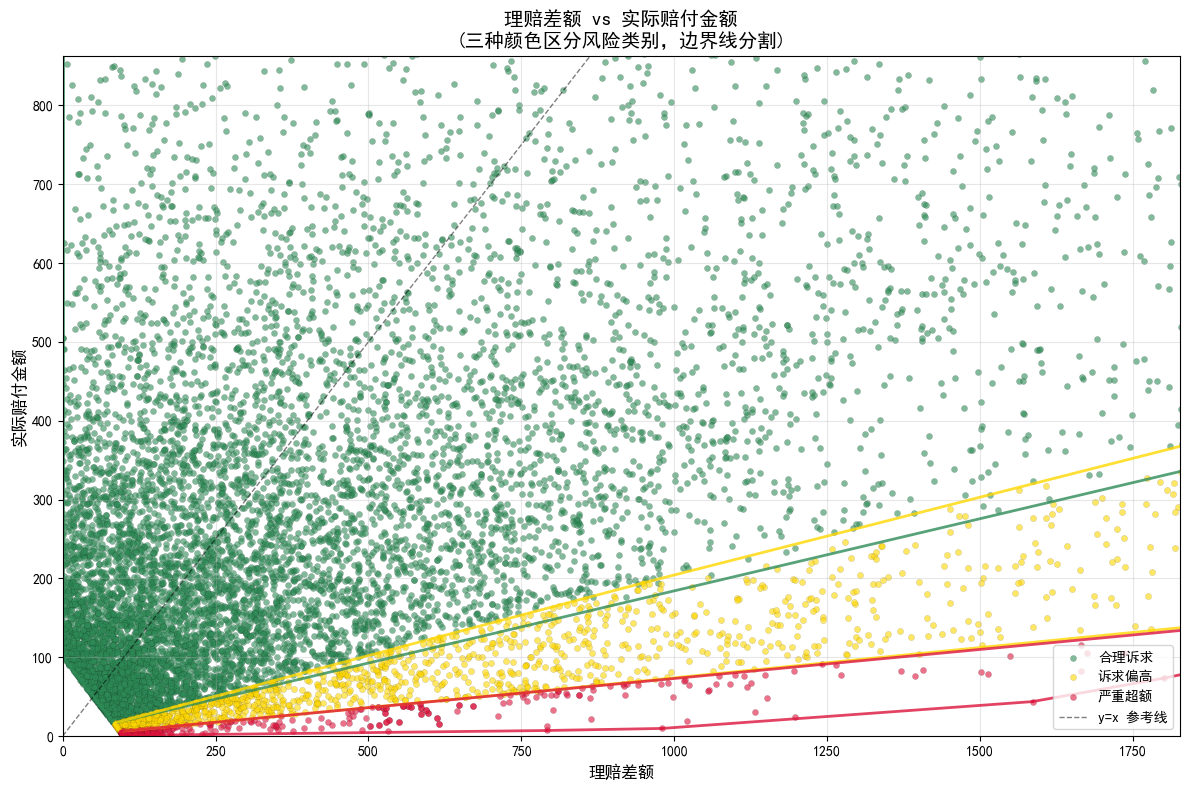


散点图统计信息:
虚报比例范围: [0.0001, 0.9926]
理赔差额范围: [0.08, 4463.58]
实际赔付金额范围: [0.74, 3171.47]

各风险类别虚报比例分析:
合理诉求: 平均虚报比例=0.5304, 中位数=0.5729, 样本数=9493
诉求偏高: 平均虚报比例=0.8805, 中位数=0.8792, 样本数=1339
严重超额: 平均虚报比例=0.9575, 中位数=0.9553, 样本数=335
改进散点图分析完成！


In [8]:
# 7. 改进的散点图分析 - 添加分类边界和虚报比例颜色映射
print("\n7. 改进的散点图分析...")

# 计算虚报比例 (理赔差额 / 索赔金额)
df['虚报比例'] = df['理赔差额'] / df['索赔金额']

# 创建散点图，按风险类别用三种固定颜色
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# 定义三种颜色和标签
risk_labels = ['合理诉求', '诉求偏高', '严重超额']
colors = ['#2E8B57', '#FFD700', '#DC143C']  # 绿色、黄色、红色

# 为每个风险类别绘制散点
for i, label in enumerate(risk_labels):
    subset = df[df['风险标注'] == label]
    if len(subset) > 0:
        ax.scatter(subset['理赔差额'], subset['实际赔付金额'], 
                  color=colors[i], alpha=0.6, s=20, 
                  edgecolors='black', linewidth=0.1, label=label)

# 绘制分类边界线
# 使用凸包算法为每个风险类别绘制边界
from scipy.spatial import ConvexHull
boundary_colors = ['#2E8B57', '#FFD700', '#DC143C']

for i, label in enumerate(risk_labels):
    subset = df[df['风险标注'] == label]
    if len(subset) > 10:  # 确保有足够的点来计算凸包
        try:
            # 计算凸包
            hull = ConvexHull(subset[['理赔差额', '实际赔付金额']].values)
            
            # 绘制凸包边界
            for simplex in hull.simplices:
                ax.plot(subset[['理赔差额', '实际赔付金额']].iloc[simplex, 0], 
                       subset[['理赔差额', '实际赔付金额']].iloc[simplex, 1], 
                       color=boundary_colors[i], linewidth=2, alpha=0.8)
        except:
            # 如果凸包计算失败，跳过
            pass

# 设置标题和标签
ax.set_title('理赔差额 vs 实际赔付金额\n(三种颜色区分风险类别，边界线分割)', fontsize=14, fontweight='bold')
ax.set_xlabel('理赔差额', fontsize=12)
ax.set_ylabel('实际赔付金额', fontsize=12)

# 添加网格
ax.grid(True, alpha=0.3)

# 添加对角线参考线 (y = x)
max_val = max(df['理赔差额'].max(), df['实际赔付金额'].max())
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=1, label='y=x 参考线')

# 添加图例
ax.legend()

# 设置坐标轴范围
ax.set_xlim(0, df['理赔差额'].quantile(0.95))  # 显示95%的数据范围
ax.set_ylim(0, df['实际赔付金额'].quantile(0.95))

plt.tight_layout()
plt.show()

# 添加统计信息
print("\n散点图统计信息:")
print(f"虚报比例范围: [{df['虚报比例'].min():.4f}, {df['虚报比例'].max():.4f}]")
print(f"理赔差额范围: [{df['理赔差额'].min():.2f}, {df['理赔差额'].max():.2f}]")
print(f"实际赔付金额范围: [{df['实际赔付金额'].min():.2f}, {df['实际赔付金额'].max():.2f}]")

# 按风险类别分析虚报比例
print("\n各风险类别虚报比例分析:")
for label in risk_labels:
    subset = df[df['风险标注'] == label]
    if len(subset) > 0:
        avg_ratio = subset['虚报比例'].mean()
        median_ratio = subset['虚报比例'].median()
        print(f"{label}: 平均虚报比例={avg_ratio:.4f}, 中位数={median_ratio:.4f}, 样本数={len(subset)}")

print("改进散点图分析完成！")


In [10]:
# 8. 生成包含风险标注的完整训练数据集
print("\n8. 生成包含风险标注的完整训练数据集...")

# 创建包含风险标注的完整训练数据集
# 将风险标注列添加到原始训练数据集的最后一列
train_with_risk = df.copy()
train_with_risk['风险标注'] = df['风险标注']

# 显示数据集基本信息
print(f"包含风险标注的训练数据集形状: {train_with_risk.shape}")
print(f"列数: {len(train_with_risk.columns)}")
print(f"新增的风险标注列位置: 第{len(train_with_risk.columns)}列")

# 显示各风险类别的统计信息
print("\n各风险类别统计:")
risk_summary = train_with_risk.groupby('风险标注').agg({
    '索赔金额': ['count', 'mean', 'std'],
    '实际赔付金额': ['mean', 'std'],
    '理赔差额': ['mean', 'std'],
    '数分位指标': ['mean', 'std'],
    '虚报比例': ['mean', 'std']
}).round(4)

print(risk_summary)

# 显示前10条记录（重点显示风险标注列）
print("\n前10条记录（显示风险标注列）:")
display_columns = ['索赔金额', '实际赔付金额', '理赔差额', '数分位指标', '虚报比例', '风险标注']
print(train_with_risk[display_columns].head(10))

# 显示后10条记录
print("\n后10条记录（显示风险标注列）:")
print(train_with_risk[display_columns].tail(10))

# 保存包含风险标注的完整训练数据集
output_filename = 'train_with_risk_annotation.csv'
train_with_risk.to_csv(output_filename, index=False, encoding='utf-8-sig')
print(f"\n包含风险标注的训练数据集已保存为: {output_filename}")

# 显示保存信息
import os
print(f"文件大小: {os.path.getsize(output_filename) / 1024:.2f} KB")
print(f"记录总数: {len(train_with_risk)}")
print(f"特征列数: {len(train_with_risk.columns) - 1}")  # 减去风险标注列
print(f"目标列: 风险标注")

# 风险类别分布
print("\n风险类别分布:")
risk_distribution = train_with_risk['风险标注'].value_counts()
for label, count in risk_distribution.items():
    percentage = count / len(train_with_risk) * 100
    print(f"{label}: {count} 条记录 ({percentage:.2f}%)")

print("\n包含风险标注的训练数据集生成完成！")



8. 生成包含风险标注的完整训练数据集...
包含风险标注的训练数据集形状: (11167, 35)
列数: 35
新增的风险标注列位置: 第35列

各风险类别统计:
      索赔金额                        实际赔付金额                理赔差额            \
     count      mean       std      mean       std      mean       std   
风险标注                                                                     
严重超额   335  466.5649  470.3569   23.5976   29.1226  442.9672  442.6931   
合理诉求  9493  811.2367  811.8054  328.0194  288.0455  483.2172  603.5190   
诉求偏高  1339  861.3328  797.0523  105.7976  108.9066  755.5352  693.4061   

        数分位指标             虚报比例          
         mean      std    mean     std  
风险标注                                    
严重超额  23.7480  12.1801  0.9575  0.0173  
合理诉求   1.6268   1.2324  0.5304  0.2145  
诉求偏高   7.7242   2.3248  0.8805  0.0294  

前10条记录（显示风险标注列）:
      索赔金额  实际赔付金额     理赔差额      数分位指标      虚报比例  风险标注
0   947.97  144.51   803.46   5.521682  0.847558  诉求偏高
1   992.87  135.98   856.89   6.255585  0.863044  诉求偏高
2   352.65  119.35   233.30   1.938513  